# AnalystLab Africa Data Analytics Internship Program
## Week 5: Business Analytics Case Study - Bank Marketing Campaign Optimization
**Prepared by:** Data Analyst Intern  
**Dataset:** Bank Marketing Dataset (`bank.csv`)  
**Objective:** Analyze direct marketing telemarketing campaign conversion, identify key drivers of subscriptions using Random Forest, and provide actionable business recommendations to maximize marketing ROI.

### 1. Setup & Data Loading
We start by importing our analytical libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`) and setting visual styles for our charts.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Set plot style for professional aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Palette definitions
PALETTE_PRIMARY = "#1e293b" # Slate 800
PALETTE_ACCENT = "#0f766e"  # Teal 700
PALETTE_MUTED = "#64748b"   # Slate 500
PALETTE_SUCCESS = "#10b981" # Emerald 500

# Load data
df = pd.read_csv("bank.csv")
df['target'] = (df['deposit'] == 'yes').astype(int)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
print(df.info())

Dataset loaded: 11162 rows, 18 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
 17  target     11162 non-null  int64 
dtypes: int64(8), object(10)
memory usage: 1.5+ MB
None


### 2. Exploratory Data Analysis & Target Distribution
Let's look at the baseline subscription conversion rate. Out of the 11,162 customer contacts, how many actually subscribed?

In [2]:
print("--- Baseline Conversion Distribution ---")
counts = df['deposit'].value_counts()
pcts = df['deposit'].value_counts(normalize=True)
for label in counts.index:
    print(f"{label.upper()}: {counts[label]} records ({pcts[label]*100:.2f}%)")

--- Baseline Conversion Distribution ---
NO: 5873 records (52.62%)
YES: 5289 records (47.38%)


### 3. Key Drivers Identification (Machine Learning)
We train a Random Forest Classifier to identify the features that carry the highest predictive importance in determining whether a client will subscribe to a term deposit.

In [3]:
# Prepare features and target
X = df.drop(columns=['deposit', 'target'])
y = df['target']

# Encode object variables
X_encoded = X.copy()
label_encoders = {}
for col in X_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

# Train Random Forest
rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_encoded, y)

# Compute Importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print("--- Random Forest Feature Importance Rankings ---")
print(importance_df.to_string(index=False))

--- Random Forest Feature Importance Rankings ---
  feature  importance
 duration    0.369488
  balance    0.088721
      age    0.083960
    month    0.082800
      day    0.071623
  contact    0.045893
    pdays    0.045500
      job    0.038356
 poutcome    0.034903
 campaign    0.033790
  housing    0.030951
education    0.022593
 previous    0.021431
  marital    0.018022
     loan    0.010586
  default    0.001383


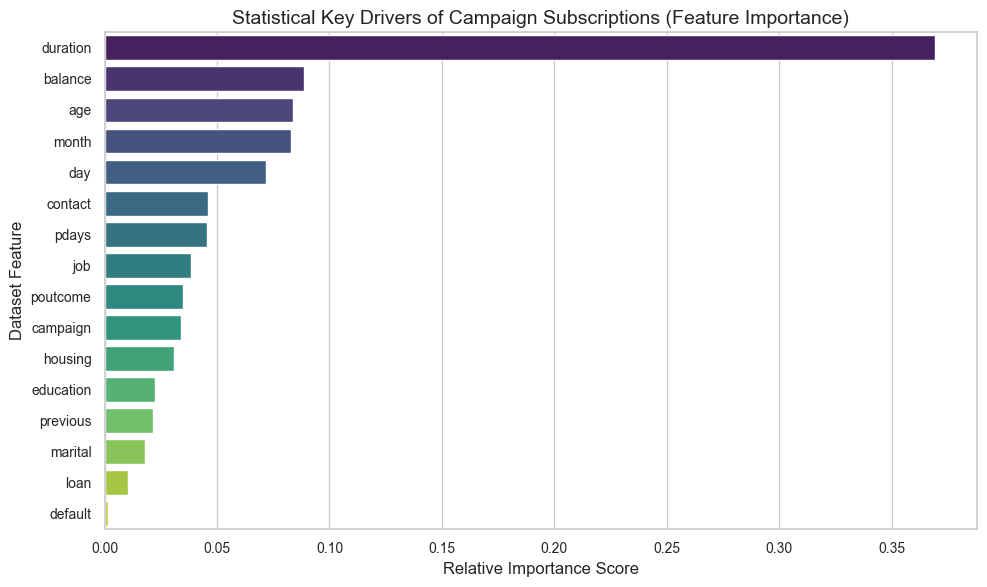

In [4]:
# Plot Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df, 
    x='importance', 
    y='feature', 
    hue='feature',
    palette=sns.color_palette("viridis", len(importance_df)),
    legend=False
)
plt.title("Statistical Key Drivers of Campaign Subscriptions (Feature Importance)")
plt.xlabel("Relative Importance Score")
plt.ylabel("Dataset Feature")
plt.tight_layout()
plt.show()

### 4. Deep Dive Analysis of Top Drivers

#### Driver 1: Call Duration (The Golden Metric)
We group call durations into quintiles to understand how client subscription probabilities relate to the length of the pitch.

--- Subscription Rates by Call Duration Bin ---
0-2 mins: 2262 calls, 9.02% conversion rate
2-3.5 mins: 2216 calls, 32.31% conversion rate
3.5-5.5 mins: 2221 calls, 48.54% conversion rate
5.5-9.5 mins: 2234 calls, 62.80% conversion rate
9.5+ mins: 2229 calls, 84.70% conversion rate


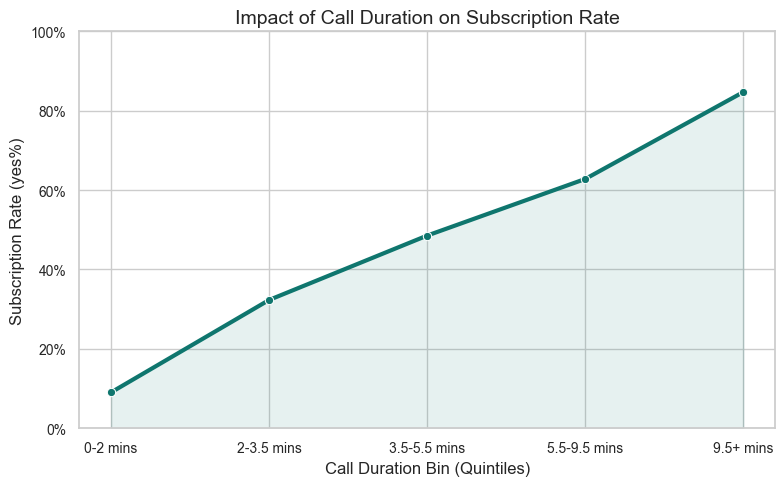

In [5]:
df['duration_group'] = pd.qcut(df['duration'], q=5, labels=['0-2 mins', '2-3.5 mins', '3.5-5.5 mins', '5.5-9.5 mins', '9.5+ mins'])
duration_stats = df.groupby('duration_group', observed=False)['target'].agg(['count', 'mean']).reset_index()

print("--- Subscription Rates by Call Duration Bin ---")
for index, row in duration_stats.iterrows():
    print(f"{row['duration_group']}: {row['count']} calls, {row['mean']*100:.2f}% conversion rate")

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=duration_stats, 
    x='duration_group', 
    y='mean', 
    marker='o', 
    linewidth=3, 
    color=PALETTE_ACCENT
)
plt.fill_between(range(len(duration_stats)), duration_stats['mean'], color=PALETTE_ACCENT, alpha=0.1)
plt.title("Impact of Call Duration on Subscription Rate")
plt.xlabel("Call Duration Bin (Quintiles)")
plt.ylabel("Subscription Rate (yes%)")
plt.ylim(0, 1.0)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.tight_layout()
plt.show()

#### Driver 2: Temporal Trends (Monthly Outreach Volume vs. Conversion Rate)
Analyzing call volume and conversions across months reveals seasonal bottlenecks and off-peak opportunities.

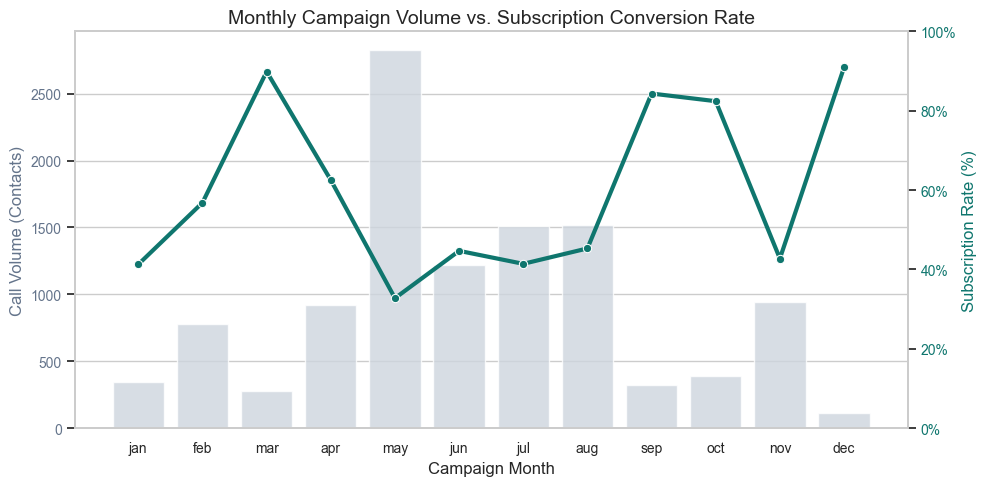

In [7]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
month_stats = df.groupby('month', observed=False)['target'].agg(['count', 'mean']).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

# Bar chart for call volume
sns.barplot(data=month_stats, x='month', y='count', ax=ax1, color='#cbd5e1', alpha=0.8)
# Line chart for conversion rate
sns.lineplot(data=month_stats, x='month', y='mean', ax=ax2, marker='o', linewidth=3, color=PALETTE_ACCENT, sort=False)

ax1.set_title("Monthly Campaign Volume vs. Subscription Conversion Rate")
ax1.set_xlabel("Campaign Month")
ax1.set_ylabel("Call Volume (Contacts)", color=PALETTE_MUTED)
ax2.set_ylabel("Subscription Rate (%)", color=PALETTE_ACCENT)
ax2.grid(False)
ax2.set_ylim(0, 1.0)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

ax1.tick_params(axis='y', labelcolor=PALETTE_MUTED)
ax2.tick_params(axis='y', labelcolor=PALETTE_ACCENT)

plt.tight_layout()
plt.show()

#### Driver 3: Diminishing Returns of Contact Frequency (`campaign`)
We investigate how repeatedly calling a client during a campaign impacts the likelihood of conversion.

--- Diminishing Returns of Contact Frequency ---
1 contact: 4798 calls, 53.38% conversion rate
2 contacts: 3028 calls, 46.27% conversion rate
3 contacts: 1321 calls, 46.78% conversion rate
4-5 contacts: 1149 calls, 39.69% conversion rate
6-10 contacts: 656 calls, 31.40% conversion rate
10+ contacts: 210 calls, 22.38% conversion rate


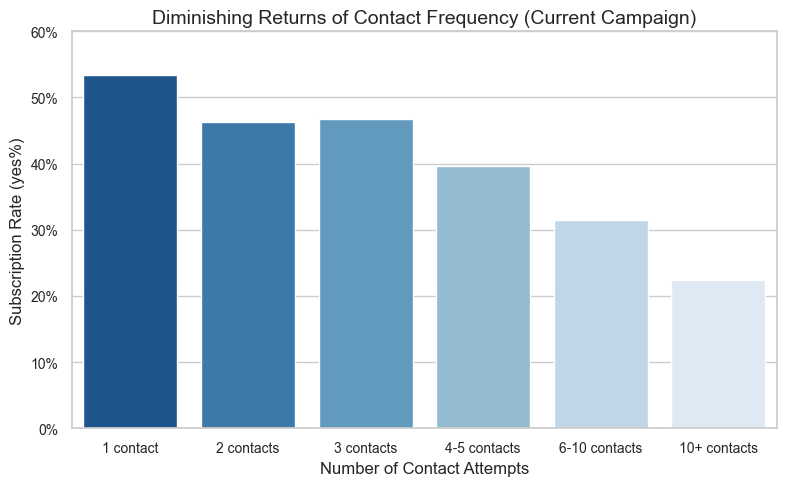

In [8]:
df['campaign_group'] = pd.cut(df['campaign'], bins=[0, 1, 2, 3, 5, 10, 100], labels=['1 contact', '2 contacts', '3 contacts', '4-5 contacts', '6-10 contacts', '10+ contacts'])
campaign_stats = df.groupby('campaign_group', observed=False)['target'].agg(['count', 'mean']).reset_index()

print("--- Diminishing Returns of Contact Frequency ---")
for idx, row in campaign_stats.iterrows():
    print(f"{row['campaign_group']}: {row['count']} calls, {row['mean']*100:.2f}% conversion rate")

plt.figure(figsize=(8, 5))
sns.barplot(data=campaign_stats, x='campaign_group', y='mean', hue='campaign_group', palette="Blues_r", legend=False)
plt.title("Diminishing Returns of Contact Frequency (Current Campaign)")
plt.xlabel("Number of Contact Attempts")
plt.ylabel("Subscription Rate (yes%)")
plt.ylim(0, 0.6)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.tight_layout()
plt.show()

#### Driver 4: Prior Campaign Outcome History (`poutcome`)
Leveraging historical interactions can isolate highly qualified warm leads.

--- Subscription Rates by Previous Campaign Outcome ---
  poutcome  count      mean
0  success   1071  0.913165
1    other    537  0.571695
2  failure   1228  0.503257
3  unknown   8326  0.406678


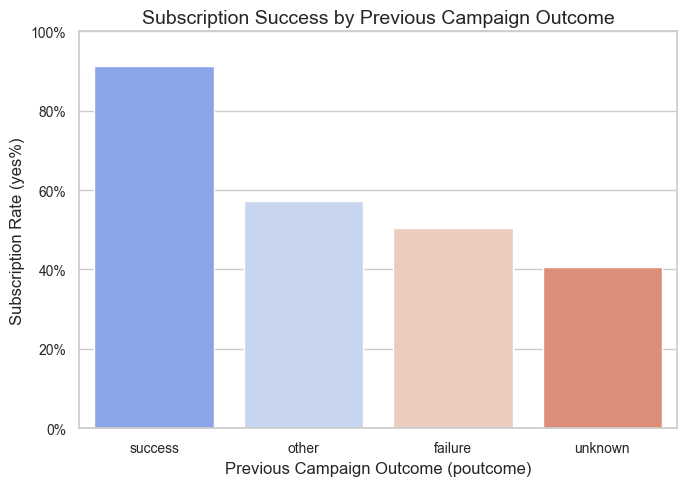

In [9]:
poutcome_stats = df.groupby('poutcome')['target'].agg(['count', 'mean']).sort_values(by='mean', ascending=False).reset_index()
print("--- Subscription Rates by Previous Campaign Outcome ---")
print(poutcome_stats)

plt.figure(figsize=(7, 5))
sns.barplot(data=poutcome_stats, x='poutcome', y='mean', hue='poutcome', palette="coolwarm", legend=False)
plt.title("Subscription Success by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome (poutcome)")
plt.ylabel("Subscription Rate (yes%)")
plt.ylim(0, 1.0)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.tight_layout()
plt.show()

### 5. Demographics and Segmentation Insights
We analyze demographic profiles (occupation and age) and financial obligations (housing/personal loans) to identify low-performing and high-performing cohorts.

--- Subscription Conversion Rates by Occupation ---
              job  count      mean
0         student    360  0.747222
1         retired    778  0.663239
2      unemployed    357  0.565826
3      management   2566  0.507015
4         unknown     70  0.485714
5          admin.   1334  0.473013
6   self-employed    405  0.461728
7      technician   1823  0.460779
8        services    923  0.399783
9       housemaid    274  0.397810
10   entrepreneur    328  0.375000
11    blue-collar   1944  0.364198


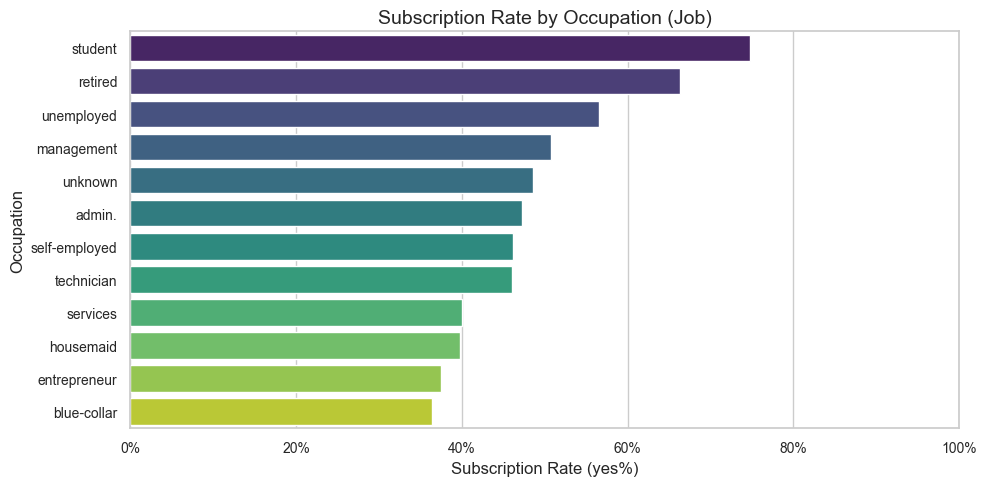

In [10]:
# Occupation Analysis
job_stats = df.groupby('job')['target'].agg(['count', 'mean']).sort_values(by='mean', ascending=False).reset_index()
print("--- Subscription Conversion Rates by Occupation ---")
print(job_stats)

plt.figure(figsize=(10, 5))
sns.barplot(data=job_stats, x='mean', y='job', hue='job', palette="viridis", legend=False)
plt.title("Subscription Rate by Occupation (Job)")
plt.xlabel("Subscription Rate (yes%)")
plt.ylabel("Occupation")
plt.xlim(0, 1.0)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
plt.tight_layout()
plt.show()

In [11]:
# Demographic & Financial cross-tabulations
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 100], labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+'])
print("--- Deposit rate by Age Group ---")
print(df.groupby('age_group', observed=False)['target'].agg(['count', 'mean']))

print("\n--- Deposit rate by Housing Loan Status ---")
print(df.groupby('housing')['target'].agg(['count', 'mean']))

print("\n--- Deposit rate by Personal Loan Status ---")
print(df.groupby('loan')['target'].agg(['count', 'mean']))

--- Deposit rate by Age Group ---
           count      mean
age_group                 
<25          450  0.711111
25-34       3921  0.476664
35-44       3158  0.411970
45-54       2149  0.415542
55-64       1086  0.539595
65+          398  0.804020

--- Deposit rate by Housing Loan Status ---
         count      mean
housing                 
no        5881  0.570311
yes       5281  0.366408

--- Deposit rate by Personal Loan Status ---
      count      mean
loan                 
no     9702  0.495259
yes    1460  0.331507


### 6. Summary of Key Insights & Strategic Recommendations

#### Insights:
1. **Call Duration**: Keeping the client engaged past the 3.5-minute mark dramatically increases subscription probability.
2. **May Outreach Volume**: The bank is placing too many low-performing cold calls in May (conversion 32.76%), creating campaign fatigue and higher acquisition cost.
3. **Call Capping**: Re-calling a client more than 3 times is an operational waste, as subscription drops off rapidly after 3 attempts.
4. **Receptive Cohorts**: Students, retirees, warm leads (prior successes), and clients with higher balances convert at high rates.
5. **High-Risk Cohorts**: Debtors (active personal/housing loans), blue-collar workers, and contacts without cellular information have poor conversion.

#### Strategic Actions:
- **Action 1**: Shift agent outreach capacity from May to high-performing off-peak months (March, September, October, and December).
- **Action 2**: Enforce a hard cap of 3 contact attempts per client per campaign to reduce resource waste and prevent customer irritation.
- **Action 3**: Pitch tailored financial packages: low-risk steady yields to retirees, high-yield flexible terms to students. Stop pitching deposits to active debtors.
- **Action 4**: Enforce database enrichment to prioritize cellular channels and eliminate the 'unknown' channel category.